# NB02 — Leakage Ablation: Naive vs. Specimen-Disjoint Splitting

Trains two independently initialised models, identical in architecture,
hyperparameters, and seed — one on the naive (image-level) split and one on the
specimen-disjoint split from NB01 — then scores each on two test sets: its own
held-out test partition, and the shared `common_test` set that neither model ever
trained on. The difference between own-test and common-test accuracy separates two
quantities a single-model, single-test-set evaluation cannot distinguish: the
**reporting inflation** naive splitting produces (each condition scored on the protocol
it was trained under) and the **true generalisation gap** (both conditions scored on
the same untouched set).

A design note on why two independently trained models are used rather than one model
scored on two test sets: scoring a single naive-split-trained model on both its own
test partition and a specimen-disjoint test partition confounds reporting inflation
with ordinary training variance, and is invalid whenever the naive split was drawn
without any constraint against the specimen-disjoint partition — in that case a large
share of the "held-out" specimen-disjoint test images may already appear in the naive
training set, inflating that comparison independently of any real leakage effect.
Training two separately seeded models under each protocol and scoring both on a
genuinely shared, never-trained-on test set avoids this confound.

### Models
ResNet-50 and ViT-Base/16 — chosen to span a near-saturated case (ResNet-50) and a case
with substantial remaining headroom (ViT-Base/16, in-distribution accuracy 0.9785),
since only a model with headroom left can reveal whether naive splitting inflates
accuracy or merely reshuffles errors near ceiling.

**Runtime:** ResNet-50 ≈ 1.5 h, ViT-Base/16 ≈ 6 h → ≈ 7.5 h total; fits one 12-hour
session. Set `MODELS` to a single entry to split the run across accounts.


In [1]:
# ===== Imports =====
import os, json, time, random, warnings, math
from pathlib import Path
from collections import defaultdict, Counter
import numpy as np, pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
import timm

from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
    precision_score, recall_score, matthews_corrcoef, confusion_matrix, roc_auc_score)

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')


device: cuda | Tesla T4


In [2]:
# ===== Config =====
RAW_DATASET_DIR = '/kaggle/input/datasets/alenmaruf/bdlithi/Dataset'   # <-- EDIT: folder containing the 11 class sub-folders
SPLITS_DIR = Path('/kaggle/input/datasets/alenmaruf/bdlitchi-revision-splits/revision_splits')   # <-- NB01 output dataset
OUT_DIR    = Path('/kaggle/working/revision_ablation'); OUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR   = OUT_DIR/'checkpoints'; CKPT_DIR.mkdir(exist_ok=True)

MODELS   = ['ResNet50', 'ViTBase16']   # <-- run one per account if you prefer

# MULTIPLE SEEDS ARE REQUIRED HERE.
# NB04 measured ViT-Base/16 seed-to-seed s.d. of 2.32 pp on the common test set. The
# difference between two independently trained models therefore carries ~3.3 pp of
# noise. A single-seed ablation cannot tell a 2 pp leakage effect from run-to-run
# variation. Each seed gives one paired (naive, group) observation; the claim rests
# on the MEAN across seeds and its spread, not on any single run.
SEEDS    = [42, 123, 7]
EPOCHS   = 30

# EARLY STOPPING MUST BE DISABLED FOR THIS COMPARISON.
# With patience=7 the first run showed a confound: the specimen-disjoint validation
# set is harder and noisier, so val loss plateaued sooner and training was cut short
# for the GROUP condition while the NAIVE condition ran nearly the full 30 epochs
# (ViT group best epochs 5/10/21 vs naive 27/28/29). Correlation between the group
# run's stopping epoch and the measured "inflation" was -0.90 - i.e. most of the
# apparent leakage effect was really undertraining of the group model.
#
# Setting PATIENCE = EPOCHS gives both conditions an identical training budget; the
# best-validation checkpoint is still selected, so nothing else changes. The split is
# then the only difference between the two arms, which is the point of the ablation.
PATIENCE = EPOCHS      # = no early stopping
SAVE_CHECKPOINTS = True

In [3]:
def set_all_seeds(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [4]:
IMAGENET_MEAN=[0.485,0.456,0.406]; IMAGENET_STD=[0.229,0.224,0.225]

class LitchiDataset(Dataset):
    def __init__(self, df, transform, label2idx, grayscale=False):
        self.df=df.reset_index(drop=True); self.t=transform
        self.l2i=label2idx; self.gray=grayscale
    def __len__(self): return len(self.df)
    def __getitem__(self,i):
        r=self.df.iloc[i]; img=Image.open(r.filepath).convert('RGB')
        if self.gray:
            img = img.convert('L').convert('RGB')   # drop colour, keep 3 channels
        return self.t(img), self.l2i[r.label]

def make_transforms(sz, augment):
    if augment:
        tr=transforms.Compose([transforms.Resize((sz+32,sz+32)), transforms.RandomCrop(sz),
            transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
            transforms.ColorJitter(0.3,0.3,0.2,0.05), transforms.RandomRotation(20),
            transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)])
    else:
        tr=transforms.Compose([transforms.Resize((sz,sz)), transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)])
    ev=transforms.Compose([transforms.Resize((sz,sz)), transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)])
    return tr,ev

def build_backbone(name, nc, pretrained=True):
    if name=='ResNet50':
        m=torchvision.models.resnet50(weights='IMAGENET1K_V2' if pretrained else None)
        m.fc=nn.Linear(m.fc.in_features,nc); return m,224,32
    if name=='MobileNetV3Large':
        m=torchvision.models.mobilenet_v3_large(weights='IMAGENET1K_V2' if pretrained else None)
        m.classifier[-1]=nn.Linear(m.classifier[-1].in_features,nc); return m,224,32
    if name=='EfficientNetB0':
        return timm.create_model('efficientnet_b0',pretrained=pretrained,num_classes=nc),224,32
    if name=='EfficientNetB3':
        return timm.create_model('efficientnet_b3',pretrained=pretrained,num_classes=nc),300,16
    if name=='ViTBase16':
        return timm.create_model('vit_base_patch16_224',pretrained=pretrained,num_classes=nc),224,16
    raise ValueError(name)


In [5]:
def train_model(name, trn_df, val_df, label2idx, seed, epochs=30, patience=7,
                lr=3e-4, wd=1e-4, grayscale=False, log_every=1):
    """Independent training run. Returns (model, history, best_epoch)."""
    set_all_seeds(seed)
    nc=len(label2idx)
    model,sz,bs = build_backbone(name,nc); model=model.to(device)
    ttf,etf = make_transforms(sz, augment=True)
    trn=DataLoader(LitchiDataset(trn_df,ttf,label2idx,grayscale), batch_size=bs, shuffle=True,
                   num_workers=2, pin_memory=True, drop_last=False)
    val=DataLoader(LitchiDataset(val_df,etf,label2idx,grayscale), batch_size=bs, shuffle=False,
                   num_workers=2, pin_memory=True)
    opt=torch.optim.AdamW(model.parameters(),lr=lr,weight_decay=wd)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs)
    crit=nn.CrossEntropyLoss()
    scaler=torch.cuda.amp.GradScaler(enabled=(device.type=='cuda'))
    hist={'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}
    best=float('inf'); best_state=None; best_ep=-1; bad=0
    for ep in range(epochs):
        model.train(); rl=rc=rt=0
        for x,y in trn:
            x,y=x.to(device,non_blocking=True),y.to(device,non_blocking=True)
            opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                o=model(x); loss=crit(o,y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            rl+=loss.item()*x.size(0); rc+=(o.argmax(1)==y).sum().item(); rt+=x.size(0)
        tl,ta=rl/rt,rc/rt
        model.eval(); vl=vc=vt=0
        with torch.no_grad():
            for x,y in val:
                x,y=x.to(device),y.to(device)
                with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                    o=model(x); loss=crit(o,y)
                vl+=loss.item()*x.size(0); vc+=(o.argmax(1)==y).sum().item(); vt+=x.size(0)
        vl,va=vl/vt,vc/vt
        sch.step()
        hist['train_loss'].append(tl); hist['val_loss'].append(vl)
        hist['train_acc'].append(ta);  hist['val_acc'].append(va)
        if log_every and (ep+1)%log_every==0:
            print(f'  ep {ep+1:02d}/{epochs} train_loss={tl:.4f} acc={ta:.4f} | val_loss={vl:.4f} acc={va:.4f}')
        if vl<best-1e-5:
            best=vl; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
            best_ep=ep+1; bad=0
        else:
            bad+=1
            if bad>=patience:
                print(f'  early stop @ epoch {ep+1} (best epoch {best_ep})'); break
    model.load_state_dict(best_state)
    return model, hist, best_ep

@torch.no_grad()
def predict(model, df, label2idx, img_size, bs=32, grayscale=False):
    _,etf=make_transforms(img_size,False)
    ld=DataLoader(LitchiDataset(df,etf,label2idx,grayscale),batch_size=bs,shuffle=False,num_workers=2)
    model.eval(); P=[];Y=[];B=[]
    for x,y in ld:
        p=F.softmax(model(x.to(device)),1).cpu().numpy()
        P.extend(p.argmax(1)); Y.extend(y.numpy()); B.extend(p)
    return np.array(Y),np.array(P),np.array(B)

def metrics_dict(y,p,prob,nc):
    d=dict(accuracy=accuracy_score(y,p), balanced_accuracy=balanced_accuracy_score(y,p),
           f1_macro=f1_score(y,p,average='macro',zero_division=0),
           f1_weighted=f1_score(y,p,average='weighted',zero_division=0),
           precision_macro=precision_score(y,p,average='macro',zero_division=0),
           recall_macro=recall_score(y,p,average='macro',zero_division=0),
           mcc=matthews_corrcoef(y,p))
    try: d['roc_auc_macro']=roc_auc_score(np.eye(nc)[y],prob,average='macro',multi_class='ovr')
    except Exception: d['roc_auc_macro']=float('nan')
    return d


In [6]:
# ===== Artifact saving: predictions, probabilities, histories, calibration =====
def expected_calibration_error(y_true, y_prob, n_bins=15):
    conf = y_prob.max(1); pred = y_prob.argmax(1); acc = (pred==y_true).astype(float)
    bins=np.linspace(0,1,n_bins+1); ece=0.0; rows=[]
    for i in range(n_bins):
        m=(conf>bins[i])&(conf<=bins[i+1])
        if m.sum()==0: rows.append((float(bins[i]),float(bins[i+1]),0,np.nan,np.nan)); continue
        a,c=acc[m].mean(),conf[m].mean()
        ece+=(m.sum()/len(conf))*abs(a-c)
        rows.append((float(bins[i]),float(bins[i+1]),int(m.sum()),float(a),float(c)))
    return float(ece), rows

def save_run_artifacts(out_dir, tag, y_true, y_pred, y_prob, history=None,
                       classes=None, extra=None, specimen_ids=None, filenames=None):
    """Everything NB06 needs, with no re-inference.

    specimen_ids is essential: NB06 bootstraps by SPECIMEN, not by image. Images inside
    one specimen are the same leaf and are strongly correlated, so an image-level
    bootstrap would badly understate the confidence interval.
    """
    pdir=Path(out_dir)/'predictions'; pdir.mkdir(parents=True, exist_ok=True)
    payload=dict(y_true=np.asarray(y_true), y_pred=np.asarray(y_pred), y_prob=np.asarray(y_prob))
    if specimen_ids is not None:
        payload['specimen_id']=np.asarray(specimen_ids).astype(str)
    if filenames is not None:
        payload['filename']=np.asarray(filenames).astype(str)
    np.savez_compressed(pdir/f'{tag}.npz', **payload)
    if history is not None:
        hdir=Path(out_dir)/'histories'; hdir.mkdir(parents=True, exist_ok=True)
        json.dump(history, open(hdir/f'{tag}.json','w'))
    ece,bins = expected_calibration_error(np.asarray(y_true), np.asarray(y_prob))
    cdir=Path(out_dir)/'calibration'; cdir.mkdir(parents=True, exist_ok=True)
    json.dump({'tag':tag,'ece':ece,'bins':bins,'classes':classes,**(extra or {})},
              open(cdir/f'{tag}.json','w'), indent=2)
    return ece


In [7]:
# ===== Load frozen splits from NB01 =====
man = pd.read_csv(SPLITS_DIR/'manifest_full.csv')
# ===== Rebuild image paths for THIS session =====
# manifest_full.csv stores absolute paths from the machine that ran NB01. Kaggle mounts
# datasets at different locations per session/account, so those paths are not portable.
# Rebuild them from RAW_DATASET_DIR + label + filename, then verify every file exists.
man['filepath'] = [str(Path(RAW_DATASET_DIR)/l/f) for l,f in zip(man.label, man.filename)]
missing = [p for p in man.filepath if not Path(p).exists()]
if missing:
    print(f'*** {len(missing)} of {len(man)} images NOT found. First few:')
    for p in missing[:5]: print('   ', p)
    print('\nFix RAW_DATASET_DIR above. It must be the folder that directly contains the')
    print('11 class sub-folders. Check the exact mount with:')
    print("   import os; print(os.listdir('/kaggle/input'))")
    raise FileNotFoundError(f'{len(missing)} images missing - stop here, do not train.')
print(f'OK - all {len(man)} image paths resolve in this session.')

CLASSES = sorted(man.label.unique()); NC=len(CLASSES)
label2idx={c:i for i,c in enumerate(CLASSES)}
print('images',len(man),'classes',NC)

common_test = man[man.reserve=='common_test']
pool        = man[man.reserve=='pool']

sets = {
 'naive': dict(train=pool[pool.naive_split=='train'], val=pool[pool.naive_split=='val'],
               test=pool[pool.naive_split=='test']),
 'group': dict(train=pool[pool.group_split=='train'], val=pool[pool.group_split=='val'],
               test=pool[pool.group_split=='test']),
}
for k,v in sets.items():
    print(f'{k:6s} train={len(v["train"]):5d} val={len(v["val"]):4d} test={len(v["test"]):4d}')
print(f'common_test={len(common_test)}')

# sanity: common_test must not appear in any training set
for k,v in sets.items():
    ov=set(v['train'].filename)&set(common_test.filename)
    assert not ov, f'{k} train overlaps common_test ({len(ov)} images)'
print('OK - common_test is unseen by both conditions')

OK - all 11094 image paths resolve in this session.
images 11094 classes 11
naive  train= 6601 val=1414 test=1414
group  train= 6625 val=1397 test=1407
common_test=1665
OK - common_test is unseen by both conditions


In [8]:
# ===== Run the ablation (paired over seeds) =====
records=[]; results={}
for arch in MODELS:
    results[arch]={}
    for seed in SEEDS:
        results[arch][seed]={}
        for cond in ['naive','group']:
            print(f'\n{"="*64}\nTRAIN  {arch}  |  {cond}  |  seed={seed}\n{"="*64}')
            t0=time.time()
            model,hist,best_ep = train_model(arch, sets[cond]['train'], sets[cond]['val'],
                                             label2idx, seed=seed, epochs=EPOCHS, patience=PATIENCE)
            mins=(time.time()-t0)/60
            _,img_size,bs = build_backbone(arch,NC,pretrained=False)

            yo,po,pro = predict(model, sets[cond]['test'], label2idx, img_size, bs)
            m_own = metrics_dict(yo,po,pro,NC)
            save_run_artifacts(OUT_DIR, f'{arch}_{cond}_seed{seed}_owntest', yo,po,pro,
                               history=hist, classes=CLASSES,
                               extra={'set':'own_test','model':arch,'cond':cond,'seed':seed},
                               specimen_ids=sets[cond]['test'].specimen_id.values,
                               filenames=sets[cond]['test'].filename.values)

            yc,pc_,prc = predict(model, common_test, label2idx, img_size, bs)
            m_com = metrics_dict(yc,pc_,prc,NC)
            ece = save_run_artifacts(OUT_DIR, f'{arch}_{cond}_seed{seed}_commontest', yc,pc_,prc,
                               history=hist, classes=CLASSES,
                               extra={'set':'common_test','model':arch,'cond':cond,'seed':seed},
                               specimen_ids=common_test.specimen_id.values,
                               filenames=common_test.filename.values)

            results[arch][seed][cond]={'own_test':m_own,'common_test':m_com,
                                       'best_epoch':best_ep,'train_minutes':round(mins,1),
                                       'ece_common_test':ece,'history':hist}
            records.append({'model':arch,'seed':seed,'condition':cond,
                            'own_test_acc':m_own['accuracy'],'own_test_f1':m_own['f1_macro'],
                            'common_test_acc':m_com['accuracy'],'common_test_f1':m_com['f1_macro'],
                            'train_minutes':round(mins,1)})
            if SAVE_CHECKPOINTS:
                torch.save(model.state_dict(), CKPT_DIR/f'{arch}_{cond}_seed{seed}.pt')
            # write incrementally so a timeout does not lose finished runs
            pd.DataFrame(records).to_csv(OUT_DIR/'ablation_runs.csv',index=False)
            json.dump(results, open(OUT_DIR/'ablation_full.json','w'), indent=2, default=float)
            print(f'  own_test    acc={m_own["accuracy"]:.4f} f1={m_own["f1_macro"]:.4f}')
            print(f'  common_test acc={m_com["accuracy"]:.4f} f1={m_com["f1_macro"]:.4f}  ({mins:.1f} min)')
            del model; torch.cuda.empty_cache()
print('\nAll runs complete.')


TRAIN  ResNet50  |  naive  |  seed=42
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 185MB/s]


  ep 01/30 train_loss=0.3138 acc=0.9136 | val_loss=0.0552 acc=0.9887
  ep 02/30 train_loss=0.0790 acc=0.9768 | val_loss=0.0237 acc=0.9922
  ep 03/30 train_loss=0.0545 acc=0.9841 | val_loss=0.0879 acc=0.9689
  ep 04/30 train_loss=0.0411 acc=0.9879 | val_loss=0.0347 acc=0.9901
  ep 05/30 train_loss=0.0248 acc=0.9929 | val_loss=0.0094 acc=0.9965
  ep 06/30 train_loss=0.0296 acc=0.9917 | val_loss=0.0045 acc=0.9993
  ep 07/30 train_loss=0.0243 acc=0.9935 | val_loss=0.0120 acc=0.9965
  ep 08/30 train_loss=0.0309 acc=0.9909 | val_loss=0.0119 acc=0.9965
  ep 09/30 train_loss=0.0135 acc=0.9961 | val_loss=0.0065 acc=0.9979
  ep 10/30 train_loss=0.0127 acc=0.9955 | val_loss=0.0111 acc=0.9950
  ep 11/30 train_loss=0.0077 acc=0.9971 | val_loss=0.0019 acc=1.0000
  ep 12/30 train_loss=0.0148 acc=0.9953 | val_loss=0.0137 acc=0.9958
  ep 13/30 train_loss=0.0097 acc=0.9968 | val_loss=0.0082 acc=0.9972
  ep 14/30 train_loss=0.0086 acc=0.9980 | val_loss=0.0060 acc=0.9986
  ep 15/30 train_loss=0.0078 acc=0

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

  ep 01/30 train_loss=1.3556 acc=0.5202 | val_loss=0.5226 acc=0.8182
  ep 02/30 train_loss=0.5355 acc=0.8173 | val_loss=0.4178 acc=0.8670
  ep 03/30 train_loss=0.4640 acc=0.8462 | val_loss=0.2985 acc=0.8876
  ep 04/30 train_loss=0.3622 acc=0.8790 | val_loss=0.3106 acc=0.8925
  ep 05/30 train_loss=0.3164 acc=0.8943 | val_loss=0.2322 acc=0.9229
  ep 06/30 train_loss=0.2867 acc=0.9114 | val_loss=0.3963 acc=0.8713
  ep 07/30 train_loss=0.2716 acc=0.9115 | val_loss=0.2154 acc=0.9307
  ep 08/30 train_loss=0.2386 acc=0.9224 | val_loss=0.2893 acc=0.8840
  ep 09/30 train_loss=0.2183 acc=0.9308 | val_loss=0.2533 acc=0.9173
  ep 10/30 train_loss=0.2221 acc=0.9271 | val_loss=0.1926 acc=0.9307
  ep 11/30 train_loss=0.1911 acc=0.9374 | val_loss=0.1932 acc=0.9406
  ep 12/30 train_loss=0.1674 acc=0.9456 | val_loss=0.1444 acc=0.9470
  ep 13/30 train_loss=0.1698 acc=0.9432 | val_loss=0.1868 acc=0.9364
  ep 14/30 train_loss=0.1519 acc=0.9500 | val_loss=0.1736 acc=0.9463
  ep 15/30 train_loss=0.1240 acc=0

  ep 01/30 train_loss=1.2904 acc=0.5451 | val_loss=1.7682 acc=0.6099
  ep 02/30 train_loss=0.5575 acc=0.8092 | val_loss=0.8311 acc=0.7695
  ep 03/30 train_loss=0.3772 acc=0.8750 | val_loss=0.4770 acc=0.8590
  ep 04/30 train_loss=0.3110 acc=0.8977 | val_loss=0.9427 acc=0.7094
  ep 05/30 train_loss=0.3486 acc=0.8880 | val_loss=0.4645 acc=0.8511
  ep 06/30 train_loss=0.2763 acc=0.9061 | val_loss=0.5090 acc=0.8568
  ep 07/30 train_loss=0.2702 acc=0.9088 | val_loss=0.5416 acc=0.8182
  ep 08/30 train_loss=0.2195 acc=0.9205 | val_loss=0.5027 acc=0.8497
  ep 09/30 train_loss=0.1980 acc=0.9357 | val_loss=0.5931 acc=0.7967
  ep 10/30 train_loss=0.1704 acc=0.9431 | val_loss=0.5471 acc=0.8497
  ep 11/30 train_loss=0.1608 acc=0.9484 | val_loss=0.4438 acc=0.8669
  ep 12/30 train_loss=0.1575 acc=0.9469 | val_loss=0.3421 acc=0.9005
  ep 13/30 train_loss=0.1492 acc=0.9523 | val_loss=0.3255 acc=0.8812
  ep 14/30 train_loss=0.1288 acc=0.9564 | val_loss=0.4261 acc=0.8547
  ep 15/30 train_loss=0.1093 acc=0

In [9]:
# ===== Headline numbers: mean effect across seeds, with spread =====
from scipy.stats import wilcoxon, ttest_rel
runs=pd.DataFrame(records)
rows=[]
for arch in MODELS:
    a=runs[runs.model==arch]
    piv_own=a.pivot_table(index='seed',columns='condition',values='own_test_acc')
    piv_com=a.pivot_table(index='seed',columns='condition',values='common_test_acc')
    infl = (piv_own['naive']-piv_own['group']).values      # reporting inflation, per seed
    gap  = (piv_com['group']-piv_com['naive']).values      # true generalisation gap, per seed
    n=len(infl)
    def summarise(v,label):
        mu,sd=float(np.mean(v)),float(np.std(v,ddof=1)) if n>1 else (float(np.mean(v)),float('nan'))
        out={'effect':label,'mean':mu,'sd':sd,'n_seeds':n,
             'per_seed':', '.join(f'{x:+.4f}' for x in v)}
        if n>=3:
            try:
                t,p=ttest_rel(v,np.zeros_like(v)); out['p_ttest']=float(p)
            except Exception: out['p_ttest']=float('nan')
            out['ratio_mean_over_sd']=abs(mu)/sd if sd>0 else float('inf')
        return out
    for v,lab in [(infl,'reporting_inflation'),(gap,'true_gap')]:
        r=summarise(v,lab); r['model']=arch; rows.append(r)

summary=pd.DataFrame(rows)[['model','effect','mean','sd','n_seeds','per_seed',
                            'ratio_mean_over_sd','p_ttest']]
summary.to_csv(OUT_DIR/'ablation_effects.csv',index=False)
pd.set_option('display.width',220)
print(summary.round(4).to_string(index=False))
print("""
HOW TO READ THIS
  mean            average effect across independently seeded runs
  sd              spread of that effect across seeds
  ratio           |mean| / sd. Below ~2 means the effect is not separable from
                  run-to-run noise, however large it looks in a single run.
  p_ttest         paired t-test of the per-seed effects against zero (n is small,
                  so treat it as indicative, not decisive)

Report the MEAN with its spread. Never quote a single-seed ablation number: NB04
measured a ViT seed s.d. of 2.32 pp, which is larger than the effect being claimed.""")

    model              effect    mean     sd  n_seeds                  per_seed  ratio_mean_over_sd  p_ttest
 ResNet50 reporting_inflation  0.0038 0.0041        3 +0.0014, +0.0085, +0.0014              0.9246   0.2504
 ResNet50            true_gap -0.0056 0.0072        3 -0.0060, -0.0126, +0.0018              0.7769   0.3107
ViTBase16 reporting_inflation  0.0404 0.0244        3 +0.0463, +0.0136, +0.0612              1.6577   0.1029
ViTBase16            true_gap -0.0212 0.0204        3 -0.0216, -0.0006, -0.0414              1.0391   0.2137

HOW TO READ THIS
  mean            average effect across independently seeded runs
  sd              spread of that effect across seeds
  ratio           |mean| / sd. Below ~2 means the effect is not separable from
                  run-to-run noise, however large it looks in a single run.
  p_ttest         paired t-test of the per-seed effects against zero (n is small,
                  so treat it as indicative, not decisive)

Report the MEAN with 

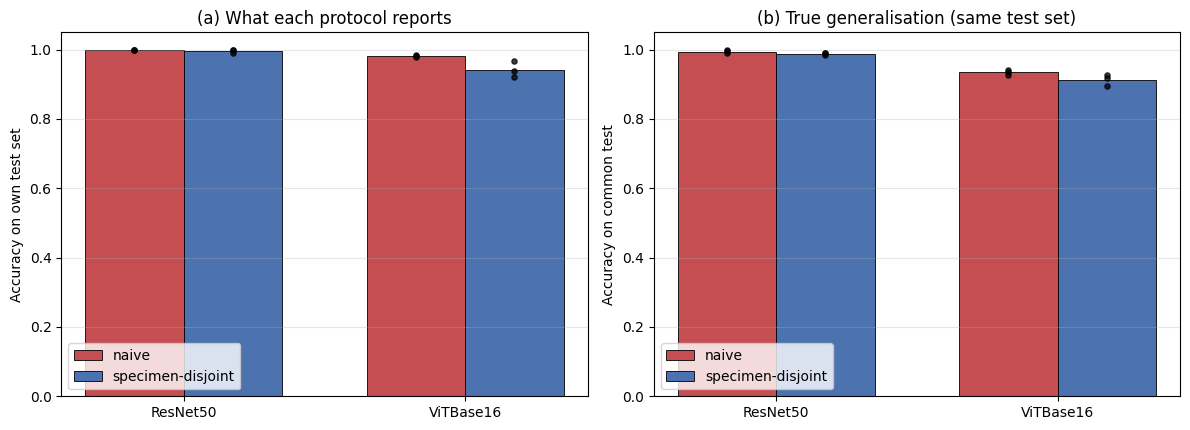

Black dots are individual seeds - if they overlap between the two bars,
the effect is not separable from seed noise.

Saved. Save /kaggle/working/revision_ablation as a Kaggle Dataset for NB06.


In [10]:
# ===== Figure: per-seed effects, so the spread is visible =====
fig,axes=plt.subplots(1,2,figsize=(12,4.4))
w=0.35; x=np.arange(len(MODELS))
for ax,(col_n,col_g,title,ylab) in zip(axes,[
    ('own_test_acc','own_test_acc','(a) What each protocol reports','Accuracy on own test set'),
    ('common_test_acc','common_test_acc','(b) True generalisation (same test set)','Accuracy on common test')]):
    for k,(cond,colr,off) in enumerate([('naive','#C44E52',-w/2),('group','#4C72B0',+w/2)]):
        means=[]; 
        for arch in MODELS:
            v=runs[(runs.model==arch)&(runs.condition==cond)][col_n].values
            means.append(np.mean(v))
            ax.scatter(np.full(len(v), x[MODELS.index(arch)]+off), v, color='black',
                       s=14, zorder=3, alpha=.75)
        ax.bar(x+off, means, w, color=colr, edgecolor='k', lw=.6,
               label=('naive' if cond=='naive' else 'specimen-disjoint'))
    ax.set_xticks(x); ax.set_xticklabels(MODELS); ax.set_ylabel(ylab)
    ax.set_title(title); ax.legend(); ax.set_ylim(0,1.05); ax.grid(axis='y',alpha=.3)
plt.tight_layout(); plt.savefig(OUT_DIR/'fig_ablation_corrected.png',dpi=300,bbox_inches='tight')
plt.show()
print('Black dots are individual seeds - if they overlap between the two bars,')
print('the effect is not separable from seed noise.')
print('\nSaved. Save /kaggle/working/revision_ablation as a Kaggle Dataset for NB06.')